#1. Installing & importing libraries

In [ ]:
!pip install yfinance
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

## 2. Fetching Stock Data


In [ ]:
stock = yf.download("AAPL", start="2023-01-01", end="2024-01-01")
print(stock.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2023-01-03  123.096031  128.834011  122.210234  128.223801  112117500
2023-01-04  124.365669  126.629372  123.105873  124.887303   89113600
2023-01-05  123.046822  125.753419  122.790931  125.123520   80962700
2023-01-06  127.574226  128.233650  122.918883  124.021209   87754700
2023-01-09  128.095840  131.304398  127.839949  128.410797   70790800


#3. Visualization
   -  Closing Price
   -  Moving Averages
   -  Daily Returns
   -  Return Distribution

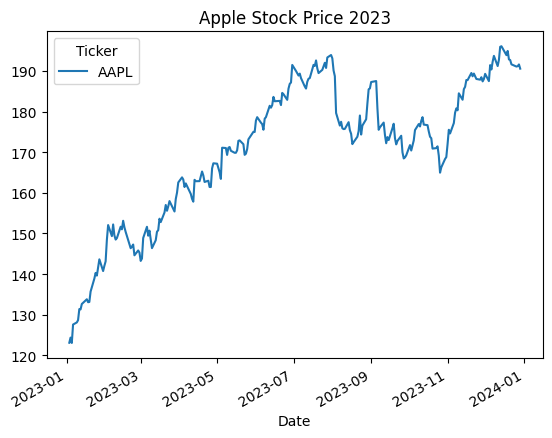

In [ ]:
stock['Close'].plot(title="Apple Stock Price 2023")
plt.show()

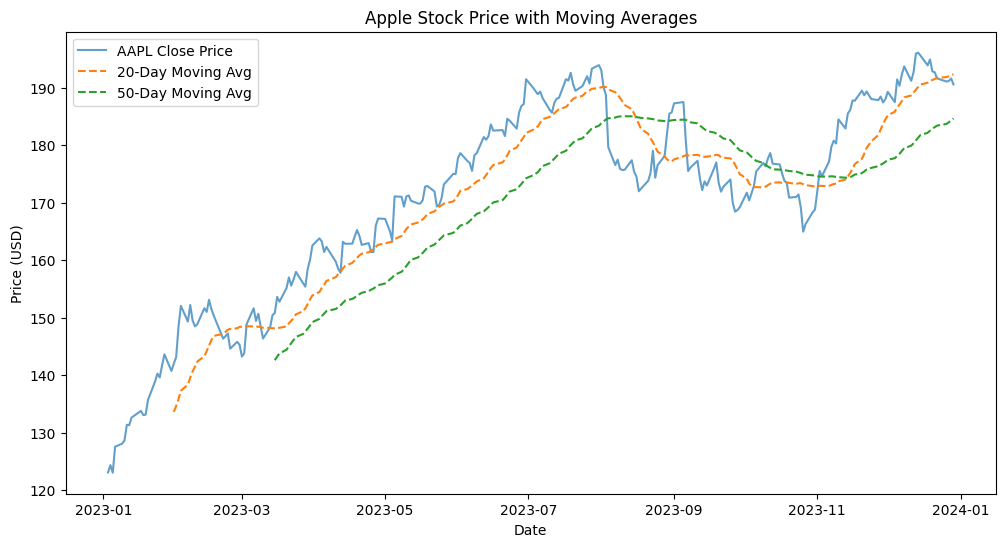

In [ ]:
stock['MA_20']= stock['Close'].rolling(window=20).mean()
stock['MA_50'] = stock['Close'].rolling(window=50).mean()

# Plot everything together
plt.figure(figsize=(12,6))
plt.plot(stock['Close'], label='AAPL Close Price', alpha=0.7)
plt.plot(stock['MA_20'], label='20-Day Moving Avg', linestyle='--')
plt.plot(stock['MA_50'], label='50-Day Moving Avg', linestyle='--')

plt.title('Apple Stock Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

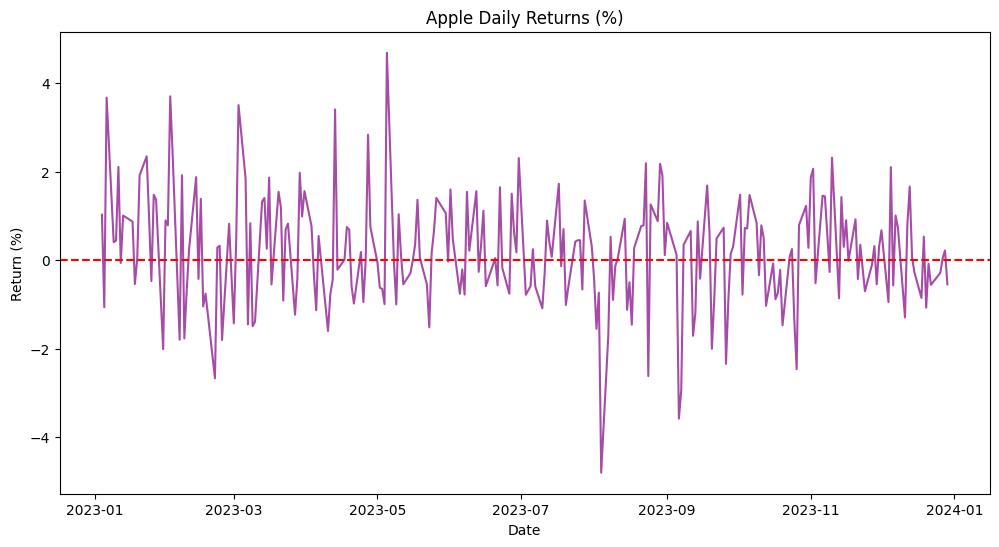

In [ ]:
# Calculate Daily Returns
stock['Daily_Return'] = stock['Close'].pct_change() * 100

# Plot Daily Returns
plt.figure(figsize=(12,6))
plt.plot(stock['Daily_Return'], color='purple', alpha=0.7)
plt.title('Apple Daily Returns (%)')
plt.xlabel('Date')
plt.ylabel('Return (%)')
plt.axhline(y=0, color='red', linestyle='--')  # Zero line
plt.show()

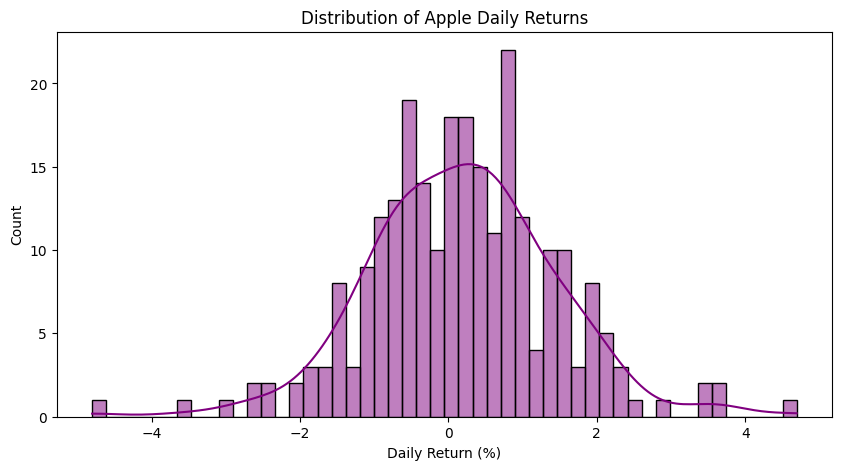

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(stock['Daily_Return'].dropna(), bins=50, kde=True, color='purple')
plt.title('Distribution of Apple Daily Returns')
plt.xlabel('Daily Return (%)')
plt.show()

# 4. Multi Stock comparision
  

*   Normalized performance
*   Correlaton Heatmap



[*********************100%***********************]  4 of 4 completed


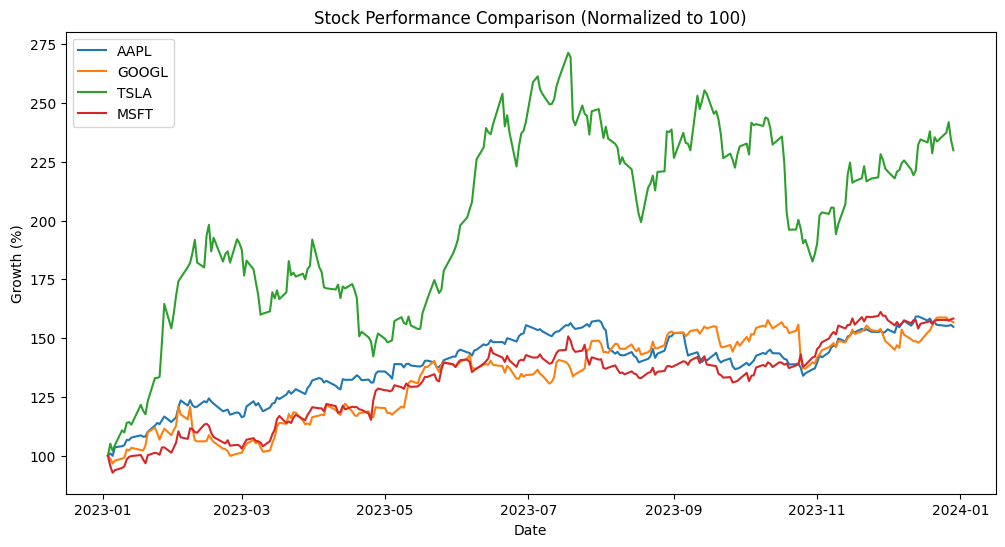

In [ ]:
# Download multiple stocks
stocks = ['AAPL', 'GOOGL', 'TSLA', 'MSFT']
data = yf.download(stocks, start="2023-01-01", end="2024-01-01")['Close']

# Normalize to 100 (so we can compare fairly)
normalized = (data / data.iloc[0]) * 100

# Plot
plt.figure(figsize=(12,6))
for stock in stocks:
    plt.plot(normalized[stock], label=stock)

plt.title('Stock Performance Comparison (Normalized to 100)')
plt.xlabel('Date')
plt.ylabel('Growth (%)')
plt.legend()
plt.show()

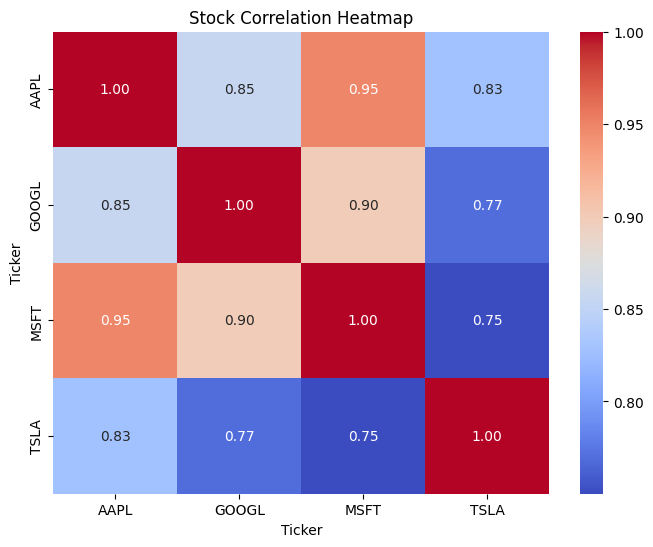

In [ ]:
# Correlation between stocks
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Stock Correlation Heatmap')
plt.show()

## 5. ARIMA Forecasting

In this section we use the ARIMA model to forecast future stock prices
based on historical patterns. ARIMA is a classic statistical model widely
used in financial time series forecasting.

In [ ]:
!pip install statsmodels

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

In [ ]:
apple = yf.download("AAPL", start="2023-01-01", end="2024-01-01")['Close']

result = adfuller(apple.dropna())
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')

if result[1] < 0.05:
    print("✅ Data is Stationary — Ready for ARIMA")
else:
    print("⚠️ Data is NOT Stationary — Applying Differencing")
    apple = apple.diff().dropna()

[*********************100%***********************]  1 of 1 completed

ADF Statistic: -2.5861
p-value: 0.0959
⚠️ Data is NOT Stationary — Applying Differencing


In [ ]:
# ARIMA(p,d,q) — standard starting parameters
model = ARIMA(apple, order=(5, 1, 0))
fitted_model = model.fit()

print(fitted_model.summary())

                               SARIMAX Results                                
Dep. Variable:                   AAPL   No. Observations:                  249
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -553.698
Date:                Fri, 13 Mar 2026   AIC                           1119.397
Time:                        16:33:06   BIC                           1140.477
Sample:                             0   HQIC                          1127.883
                                - 249                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7524      0.067    -11.244      0.000      -0.884      -0.621
ar.L2         -0.6164      0.071     -8.627      0.000      -0.756      -0.476
ar.L3         -0.3895      0.074     -5.253      0.0

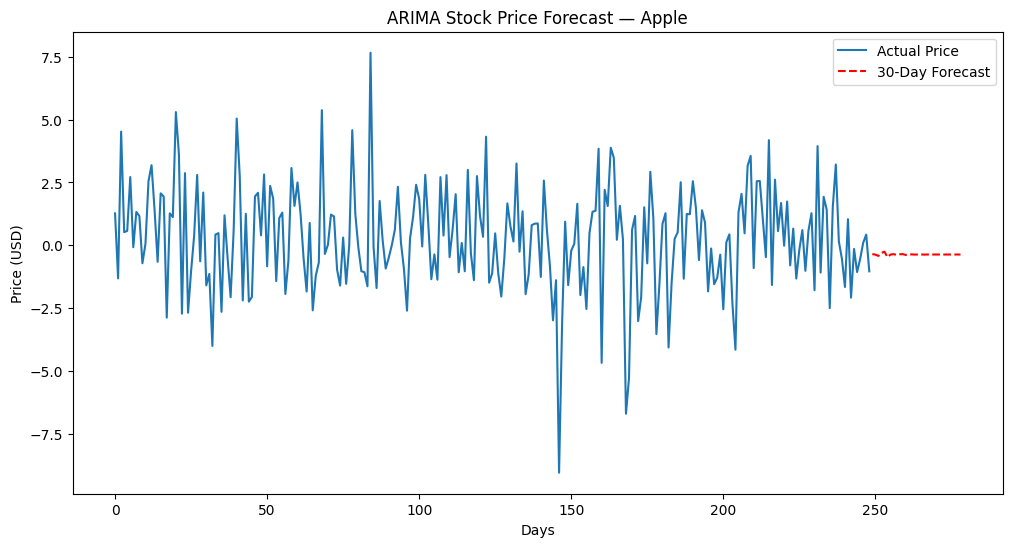

In [ ]:
# Forecast next 30 days
forecast = fitted_model.forecast(steps=30)

# Plot
plt.figure(figsize=(12,6))
plt.plot(apple.values, label='Actual Price')
plt.plot(range(len(apple), len(apple)+30),
         forecast,
         label='30-Day Forecast',
         color='red',
         linestyle='--')
plt.title('ARIMA Stock Price Forecast — Apple')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

## 6. Conclusion & Findings

In this project I analyzed Apple's stock price data for 2023 using
real-world financial data science techniques:

- **Moving Averages** revealed short and long term price trends
- **Daily Returns** showed the stock's volatility and risk profile
- **Multi-Stock Comparison** benchmarked AAPL against GOOGL, TSLA & MSFT
- **Correlation Heatmap** showed how these stocks move relative to each other
- **ARIMA Model** forecasted the next 30 days of price movement



Tools Used: Python, yfinance, Pandas, Matplotlib, Seaborn, Statsmodels